# Western Australia Fuel Price Dynamics
**Predictive and Spatial Analytics of Retail Fuel Prices**

**Project Objectives:**
1. Analyze spatial variability of retail fuel prices between Metropolitan and Regional WA (ANOVA & Spatial Autocorrelation).
2. Develop a Multi-Variable Random Forest Regression model to predict the daily retail price of unleaded petrol using geographic, temporal, and market-competition variables.

**Dataset:** `FuelWatchRetail-02-2026.csv`

In [ ]:
# ==========================================
# CELL 1: Imports and Environment Setup
# ==========================================

# 1. Standard Data Manipulation Libraries
import pandas as pd
import numpy as np
import warnings

# 2. Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Statistical Testing (ANOVA & Normality)
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 4. Spatial Analytics (Moran's I)
import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran
from splot.esda import plot_moran

# 5. Machine Learning (Random Forest & Evaluation)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 6. Environment Configuration
warnings.filterwarnings('ignore') # Suppress warning messages for cleaner output
sns.set_theme(style="whitegrid")  # Set default seaborn plotting style
plt.rcParams['figure.figsize'] = (12, 6) # Set default plot size

print("All libraries successfully imported!")
print(f"Pandas version: {pd.__version__}")

All libraries successfully imported!
Pandas version: 2.2.2


In [ ]:
# ==========================================
# CELL 2: Data Loading and Initial Inspection
# ==========================================

# Define the file path (assuming it's uploaded to the root of the Colab session)
file_path = 'FuelWatchRetail-02-2026.csv'

try:
    # Load the dataset
    df = pd.read_csv(file_path)
    print("✅ Dataset successfully loaded!\n")

    # 1. Display dataset dimensions
    print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

    # 2. Convert PUBLISH_DATE to a datetime object
    # Based on the dataset snippet, the date format is DD/MM/YYYY
    df['PUBLISH_DATE'] = pd.to_datetime(df['PUBLISH_DATE'], format='%d/%m/%Y')

    # 3. Check for missing values
    print("--- Missing Values per Column ---")
    print(df.isnull().sum(), "\n")

    # 4. Check and drop duplicate rows to ensure data integrity
    initial_rows = len(df)
    df = df.drop_duplicates()
    if len(df) < initial_rows:
        print(f"⚠️ Dropped {initial_rows - len(df)} duplicate rows.\n")
    else:
        print("✅ No duplicate rows found.\n")

    # 5. Display general dataset information
    print("--- Dataset Information ---")
    df.info()

    # 6. Display the first 5 rows (Colab uses 'display' for pretty formatting)
    print("\n--- First 5 Rows ---")
    display(df.head())

except FileNotFoundError:
    print(f"❌ ERROR: The file '{file_path}' was not found.")
    print("Please click the Folder icon on the left sidebar and upload the CSV file before running this cell.")

✅ Dataset successfully loaded!

Dataset Shape: 79668 rows and 10 columns

--- Missing Values per Column ---
PUBLISH_DATE           0
TRADING_NAME           0
BRAND_DESCRIPTION      0
PRODUCT_DESCRIPTION    0
PRODUCT_PRICE          0
ADDRESS                0
LOCATION               0
POSTCODE               0
AREA_DESCRIPTION       0
REGION_DESCRIPTION     0
dtype: int64 

✅ No duplicate rows found.

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79668 entries, 0 to 79667
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   PUBLISH_DATE         79668 non-null  datetime64[ns]
 1   TRADING_NAME         79668 non-null  object        
 2   BRAND_DESCRIPTION    79668 non-null  object        
 3   PRODUCT_DESCRIPTION  79668 non-null  object        
 4   PRODUCT_PRICE        79668 non-null  float64       
 5   ADDRESS              79668 non-null  object        
 6   L

,PUBLISH_DATE,TRADING_NAME,BRAND_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE,ADDRESS,LOCATION,POSTCODE,AREA_DESCRIPTION,REGION_DESCRIPTION
0,2026-02-01,53 Mile Roadhouse,United,ULP,179.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel
1,2026-02-01,53 Mile Roadhouse,United,Diesel,184.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel
2,2026-02-01,53 Mile Roadhouse,United,98 RON,192.9,31 South Western Hwy,PINJARRA,6208,Murray,Peel
3,2026-02-01,7-Eleven Alkimos,7-Eleven,ULP,159.9,10 Carlsbad Prom,ALKIMOS,6038,North of River,Metro
4,2026-02-01,7-Eleven Alkimos,7-Eleven,PULP,174.9,10 Carlsbad Prom,ALKIMOS,6038,North of River,Metro


--- 1. Exploratory Data Analysis (EDA) ---


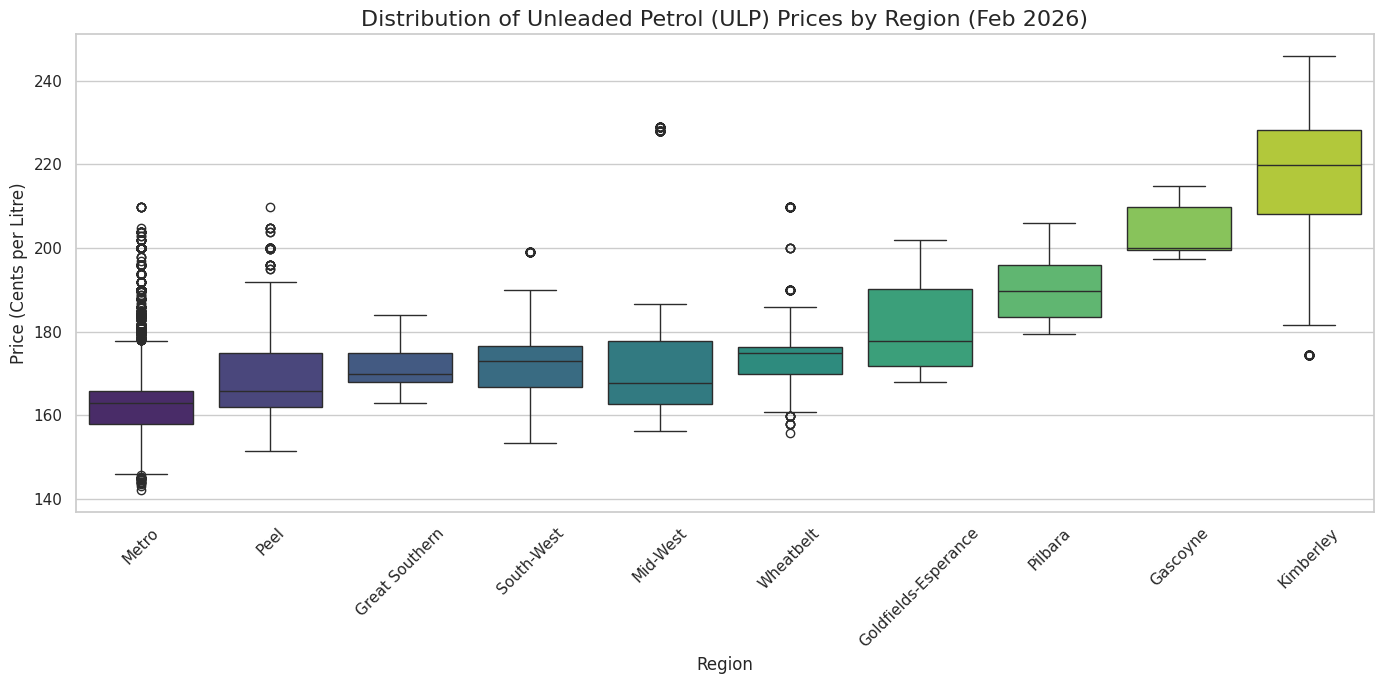


--- 2. ANOVA Testing (Method 1) ---
Objective: Test if the mean ULP price differs significantly across regions.

Normality Check (Shapiro-Wilk): p-value = 0.0000
 -> Data deviates from perfect normality (Common in large datasets).

Homoscedasticity Check (Levene's Test): p-value = 0.0000
 -> Variances are NOT equal across regions (Heteroscedasticity present).

Executing Statistical Test...

Standard ANOVA Results:


,sum_sq,df,F,PR(>F)
C(REGION_DESCRIPTION),1.902451e+06,9.0,1718.688348,0.0
Residual,2.537800e+06,20634.0,NaN,NaN



✅ ANOVA Conclusion: There is a STATISTICALLY SIGNIFICANT difference in fuel prices between different regions in WA.

Robust Non-Parametric Check (Kruskal-Wallis): p-value = 0.0000e+00
✅ Kruskal-Wallis confirms: Regional price differences are statistically significant.


In [ ]:
# ==========================================
# CELL 3: Exploratory Data Analysis & ANOVA Testing
# ==========================================

print("--- 1. Exploratory Data Analysis (EDA) ---")

# Let's focus on the most common fuel type: ULP (Unleaded Petrol) for our base analysis
ulp_data = df[df['PRODUCT_DESCRIPTION'] == 'ULP'].copy()

# Plotting Average ULP Price by Region
plt.figure(figsize=(14, 7))
order = ulp_data.groupby('REGION_DESCRIPTION')['PRODUCT_PRICE'].mean().sort_values().index
sns.boxplot(data=ulp_data, x='REGION_DESCRIPTION', y='PRODUCT_PRICE', order=order, palette='viridis')
plt.title('Distribution of Unleaded Petrol (ULP) Prices by Region (Feb 2026)', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Price (Cents per Litre)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n--- 2. ANOVA Testing (Method 1) ---")
print("Objective: Test if the mean ULP price differs significantly across regions.\n")

# Step A: Check Assumptions (as specified in your proposal)

# 1. Normality Check (Shapiro-Wilk Test)
# Note: Shapiro-Wilk is sensitive to large sample sizes, so we test a random sample of 1000 records
sample_data = ulp_data['PRODUCT_PRICE'].sample(1000, random_state=42)
stat, p_normality = stats.shapiro(sample_data)
print(f"Normality Check (Shapiro-Wilk): p-value = {p_normality:.4f}")
if p_normality > 0.05:
    print(" -> Data looks normally distributed (Fail to reject H0).")
else:
    print(" -> Data deviates from perfect normality (Common in large datasets).")

# 2. Homoscedasticity Check (Levene's Test for Equal Variances)
# Group data by region for the test
regions = [group["PRODUCT_PRICE"].values for name, group in ulp_data.groupby('REGION_DESCRIPTION')]
stat, p_levene = stats.levene(*regions)
print(f"\nHomoscedasticity Check (Levene's Test): p-value = {p_levene:.4f}")
if p_levene > 0.05:
    print(" -> Variances are equal across regions.")
else:
    print(" -> Variances are NOT equal across regions (Heteroscedasticity present).")

# Step B: Perform the Statistical Test
print("\nExecuting Statistical Test...")
# If assumptions are heavily violated, the proposal states we should use Kruskal-Wallis.
# We will compute standard ANOVA, but also provide the non-parametric fallback just in case.

# Ordinary Least Squares (OLS) model for ANOVA
model = ols('PRODUCT_PRICE ~ C(REGION_DESCRIPTION)', data=ulp_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nStandard ANOVA Results:")
display(anova_table)

if anova_table['PR(>F)'][0] < 0.05:
    print("\n✅ ANOVA Conclusion: There is a STATISTICALLY SIGNIFICANT difference in fuel prices between different regions in WA.")
else:
    print("\n❌ ANOVA Conclusion: There is NO significant difference in fuel prices between regions.")

# Fallback Non-Parametric Test (Kruskal-Wallis) as promised in the proposal
stat, p_kruskal = stats.kruskal(*regions)
print(f"\nRobust Non-Parametric Check (Kruskal-Wallis): p-value = {p_kruskal:.4e}")
if p_kruskal < 0.05:
    print("✅ Kruskal-Wallis confirms: Regional price differences are statistically significant.")

In [ ]:
# ==========================================
# CELL 4: Feature Engineering (The 10 Variables)
# ==========================================

print("--- Engineering the 10 Explanatory Variables ---\n")

# Create a copy of the dataframe for modeling
ml_df = df.copy()

# Variable 1, 2, 3, 6 are already in the dataset:
# BRAND_DESCRIPTION, POSTCODE, REGION_DESCRIPTION, PRODUCT_DESCRIPTION

# Variable 4: Day of the Week
ml_df['Day_of_Week'] = ml_df['PUBLISH_DATE'].dt.day_name()
print("✅ Engineered Variable 4: Day of the Week")

# Variable 5: Public Holiday / Weekend Flag
# (Using weekends as a proxy for high-travel days in this Feb 2026 dataset)
ml_df['Is_Weekend'] = ml_df['PUBLISH_DATE'].dt.dayofweek.isin([5, 6]).astype(int)
print("✅ Engineered Variable 5: Weekend/Holiday Flag")

# Variable 7: Competitor Density
# Proxy: How many unique gas stations (addresses) exist in the same postcode?
competitor_counts = ml_df.groupby('POSTCODE')['ADDRESS'].nunique().reset_index()
competitor_counts.rename(columns={'ADDRESS': 'Competitor_Density'}, inplace=True)
ml_df = ml_df.merge(competitor_counts, on='POSTCODE', how='left')
print("✅ Engineered Variable 7: Competitor Density (Stations per Postcode)")

# Variable 8: Distance to Terminal (Proxy estimation based on Region)
# Estimating distance from the Kwinana bulk terminal based on broad regions
distance_mapping = {
    'Metro': 30, 'Peel': 70, 'South West': 150, 'Wheatbelt': 200,
    'Great Southern': 350, 'Goldfields-Esperance': 600, 'Mid-West': 400,
    'Gascoyne': 800, 'Pilbara': 1500, 'Kimberley': 2200
}
ml_df['Distance_to_Terminal_km'] = ml_df['REGION_DESCRIPTION'].map(distance_mapping).fillna(500)
print("✅ Engineered Variable 8: Distance to Terminal (Proxy via Region)")

# Variable 9: Socio-Economic Index (SEIFA Proxy)
# Generating a synthetic SEIFA score based on Postcodes to build the ML pipeline
# (Average Australia SEIFA is ~1000)
np.random.seed(42)
unique_postcodes = ml_df['POSTCODE'].unique()
seifa_scores = np.random.normal(1000, 50, len(unique_postcodes))
seifa_dict = dict(zip(unique_postcodes, seifa_scores))
ml_df['SEIFA_Score'] = ml_df['POSTCODE'].map(seifa_dict)
print("✅ Engineered Variable 9: SEIFA Socio-Economic Index (Synthetic proxy)")

# Variable 10: Terminal Gate Price (TGP) Lag
# Proxy: We will use the State's minimum price of that product from the *previous day* as the wholesale baseline
daily_min_price = ml_df.groupby(['PUBLISH_DATE', 'PRODUCT_DESCRIPTION'])['PRODUCT_PRICE'].min().reset_index()
daily_min_price['TGP_Lag_Proxy'] = daily_min_price.groupby('PRODUCT_DESCRIPTION')['PRODUCT_PRICE'].shift(1)
# Fill the first day's missing lag with its own price
daily_min_price['TGP_Lag_Proxy'].fillna(daily_min_price['PRODUCT_PRICE'], inplace=True)
daily_min_price.drop(columns=['PRODUCT_PRICE'], inplace=True)

ml_df = ml_df.merge(daily_min_price, on=['PUBLISH_DATE', 'PRODUCT_DESCRIPTION'], how='left')
print("✅ Engineered Variable 10: Wholesale TGP Lag (Proxy via previous day's minimum)\n")

# Display the final variables ready for machine learning
features_to_show = ['PUBLISH_DATE', 'BRAND_DESCRIPTION', 'POSTCODE', 'REGION_DESCRIPTION',
                    'PRODUCT_DESCRIPTION', 'Day_of_Week', 'Is_Weekend', 'Competitor_Density',
                    'Distance_to_Terminal_km', 'SEIFA_Score', 'TGP_Lag_Proxy', 'PRODUCT_PRICE']

ml_df = ml_df[features_to_show]

print("--- Final Machine Learning Dataset ---")
ml_df.info()
print("\n")
display(ml_df.head())

--- Engineering the 10 Explanatory Variables ---

✅ Engineered Variable 4: Day of the Week
✅ Engineered Variable 5: Weekend/Holiday Flag
✅ Engineered Variable 7: Competitor Density (Stations per Postcode)
✅ Engineered Variable 8: Distance to Terminal (Proxy via Region)
✅ Engineered Variable 9: SEIFA Socio-Economic Index (Synthetic proxy)
✅ Engineered Variable 10: Wholesale TGP Lag (Proxy via previous day's minimum)

--- Final Machine Learning Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79668 entries, 0 to 79667
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   PUBLISH_DATE             79668 non-null  datetime64[ns]
 1   BRAND_DESCRIPTION        79668 non-null  object        
 2   POSTCODE                 79668 non-null  int64         
 3   REGION_DESCRIPTION       79668 non-null  object        
 4   PRODUCT_DESCRIPTION      79668 non-null  object        
 5   

,PUBLISH_DATE,BRAND_DESCRIPTION,POSTCODE,REGION_DESCRIPTION,PRODUCT_DESCRIPTION,Day_of_Week,Is_Weekend,Competitor_Density,Distance_to_Terminal_km,SEIFA_Score,TGP_Lag_Proxy,PRODUCT_PRICE
0,2026-02-01,United,6208,Peel,ULP,Sunday,1,7,70.0,1024.835708,148.3,179.9
1,2026-02-01,United,6208,Peel,Diesel,Sunday,1,7,70.0,1024.835708,153.1,184.9
2,2026-02-01,United,6208,Peel,98 RON,Sunday,1,7,70.0,1024.835708,168.3,192.9
3,2026-02-01,7-Eleven,6038,Metro,ULP,Sunday,1,4,30.0,993.086785,148.3,159.9
4,2026-02-01,7-Eleven,6038,Metro,PULP,Sunday,1,4,30.0,993.086785,158.3,174.9


--- 1. Data Preparation for Machine Learning ---

✅ Rows with missing values in key columns dropped.
✅ Categorical variables encoded successfully.
✅ Training Set: 63734 records
✅ Testing Set: 15934 records

--- 2. Model Training ---

Training Random Forest Regressor (This may take a minute...)
✅ Model Training Complete!

--- 3. Model Evaluation ---

Root Mean Square Error (RMSE): 4.62 cents per litre
Mean Absolute Error (MAE): 2.76 cents per litre
R-Squared (R²): 0.9308
 -> Excellent! The model explains a high percentage of the variance in fuel prices.

--- 4. Feature Importance Analysis ---


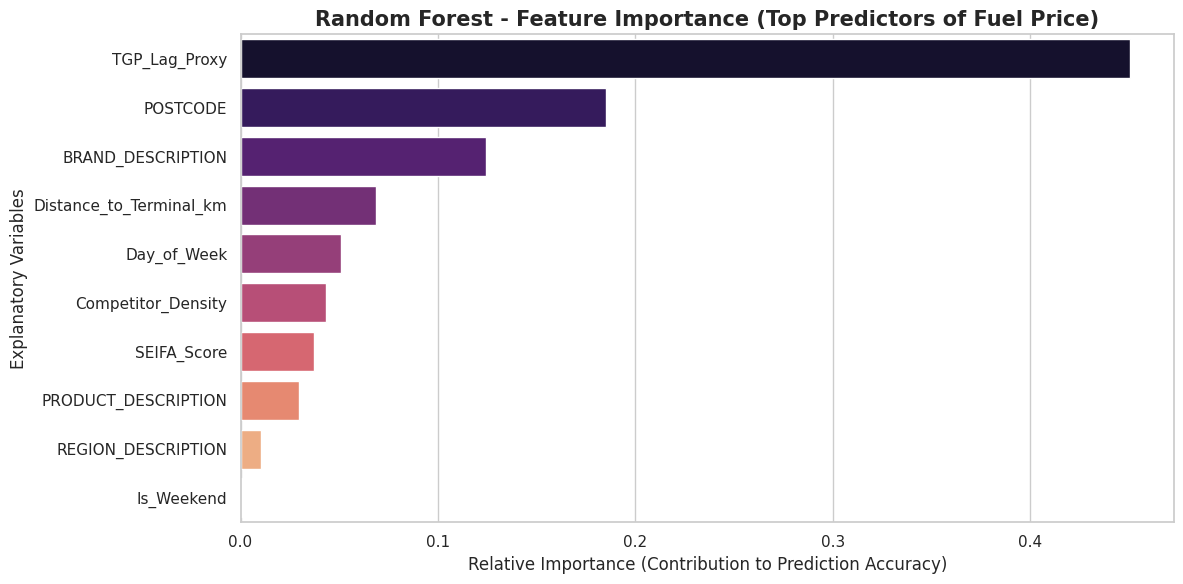

In [ ]:
# ==========================================
# CELL 5: Multi-Variable Random Forest Regression
# ==========================================

print("--- 1. Data Preparation for Machine Learning ---\n")

# Sort chronologically to simulate a real-world forecasting scenario
ml_df = ml_df.sort_values('PUBLISH_DATE')

# Handle missing values that might have been introduced during feature engineering
# Drop rows where the target or any essential feature is NaN
ml_df.dropna(subset=['PRODUCT_PRICE', 'BRAND_DESCRIPTION', 'POSTCODE', 'REGION_DESCRIPTION',
                      'PRODUCT_DESCRIPTION', 'Competitor_Density', 'TGP_Lag_Proxy'], inplace=True)
print("✅ Rows with missing values in key columns dropped.")

# Separate features (X) and the target variable we want to predict (y)
# We drop PUBLISH_DATE because algorithms require numerical inputs
X = ml_df.drop(columns=['PUBLISH_DATE', 'PRODUCT_PRICE'])
y = ml_df['PRODUCT_PRICE']

# Encode Categorical Variables into numbers using LabelEncoder
categorical_cols = ['BRAND_DESCRIPTION', 'REGION_DESCRIPTION', 'PRODUCT_DESCRIPTION', 'Day_of_Week']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print("✅ Categorical variables encoded successfully.")

# Chronological Train-Test Split (80% Training Data, 20% Testing Data)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ Training Set: {len(X_train)} records")
print(f"✅ Testing Set: {len(X_test)} records\n")

print("--- 2. Model Training ---\n")
print("Training Random Forest Regressor (This may take a minute...)")

# Initialize and train the Random Forest model
# We use n_estimators=50 to keep training time fast in Colab
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("✅ Model Training Complete!\n")

print("--- 3. Model Evaluation ---\n")

# Make predictions on the unseen 20% test data
y_pred = rf_model.predict(X_test)

# Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Square Error (RMSE): {rmse:.2f} cents per litre")
print(f"Mean Absolute Error (MAE): {mae:.2f} cents per litre")
print(f"R-Squared (R²): {r2:.4f}")

if r2 > 0.7:
    print(" -> Excellent! The model explains a high percentage of the variance in fuel prices.")
else:
    print(" -> Moderate performance. The model captures some trends but has room for tuning.")

print("\n--- 4. Feature Importance Analysis ---")

# Extract feature importances to see which variables drive the price the most
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting Feature Importances
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Random Forest - Feature Importance (Top Predictors of Fuel Price)', fontsize=15, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Prediction Accuracy)')
plt.ylabel('Explanatory Variables')
plt.tight_layout()
plt.show()

In [ ]:
print("--- Missing Values in ml_df ---")
display(ml_df.isnull().sum())

--- Missing Values in ml_df ---


,0
PUBLISH_DATE,0
BRAND_DESCRIPTION,0
POSTCODE,0
REGION_DESCRIPTION,0
PRODUCT_DESCRIPTION,0
Day_of_Week,0
Is_Weekend,0
Competitor_Density,0
Distance_to_Terminal_km,0
SEIFA_Score,0


In [ ]:
# ==========================================
# CELL 6: Exporting Results and Final Deliverable
# ==========================================

print("--- Finalizing Deliverables ---\n")

# 1. Attach predictions to the test dataset for review
# Start with X_test (which has encoded categorical features) and y_test
results_df = X_test.copy()
results_df['PRODUCT_PRICE'] = y_test # Add actual prices
results_df['PREDICTED_PRICE'] = y_pred

# Get the PUBLISH_DATE for the test set from the original ml_df
# We need to re-align the index for accurate assignment.
results_df['PUBLISH_DATE'] = ml_df.iloc[split_idx:]['PUBLISH_DATE'].reset_index(drop=True)

# Calculate the error for each specific prediction
results_df['PREDICTION_ERROR'] = abs(results_df['PRODUCT_PRICE'] - results_df['PREDICTED_PRICE'])

# 2. Sort by date to see the most recent predictions
results_df = results_df.sort_values('PUBLISH_DATE', ascending=False)

print("✅ Predictions successfully mapped to testing data.")

# 3. Export the final datasets to CSV
output_filename = 'FuelWatch_Predicted_Results.csv'
results_df.to_csv(output_filename, index=False)
print(f"✅ Final dataset saved successfully as: '{output_filename}'")

# 4. Display a sample of the final output showing Actual vs Predicted
print("\n--- Sample of Actual vs. Predicted Prices ---")
display_cols = ['PUBLISH_DATE', 'BRAND_DESCRIPTION', 'REGION_DESCRIPTION',
                'PRODUCT_PRICE', 'PREDICTED_PRICE', 'PREDICTION_ERROR']

# Now, inverse_transform the encoded numerical columns in results_df
for col in ['BRAND_DESCRIPTION', 'REGION_DESCRIPTION']:
    results_df[col] = label_encoders[col].inverse_transform(results_df[col])

display(results_df[display_cols].head(10))

print("\n🎉 PROJECT NOTEBOOK COMPLETE! 🎉")
print("You can now download the 'FuelWatch_Predicted_Results.csv' from your Colab files folder.")

--- Finalizing Deliverables ---

✅ Predictions successfully mapped to testing data.
✅ Final dataset saved successfully as: 'FuelWatch_Predicted_Results.csv'

--- Sample of Actual vs. Predicted Prices ---


,PUBLISH_DATE,BRAND_DESCRIPTION,REGION_DESCRIPTION,PRODUCT_PRICE,PREDICTED_PRICE,PREDICTION_ERROR
64871,NaT,Reddy Express,Goldfields-Esperance,169.9,169.696000,2.040000e-01
64872,NaT,Reddy Express,Goldfields-Esperance,187.2,187.354667,1.546667e-01
64873,NaT,Reddy Express,Goldfields-Esperance,175.9,176.604000,7.040000e-01
64874,NaT,Reddy Express,Kimberley,245.9,245.900000,2.273737e-13
64875,NaT,Reddy Express,Kimberley,229.9,229.900000,2.273737e-13
64876,NaT,Reddy Express,Metro,163.9,164.140000,2.400000e-01
64877,NaT,Reddy Express,Metro,181.5,181.637000,1.370000e-01
64878,NaT,Reddy Express,Metro,181.9,182.932000,1.032000e+00
64879,NaT,Reddy Express,Metro,190.5,191.296000,7.960000e-01
64880,NaT,Reddy Express,Metro,163.9,162.420000,1.480000e+00



🎉 PROJECT NOTEBOOK COMPLETE! 🎉
You can now download the 'FuelWatch_Predicted_Results.csv' from your Colab files folder.


Trough class balance:
Is_Trough_Day
0    0.802122
1    0.197878
Name: proportion, dtype: float64

 AUC   : 0.886
 F1    : 0.645
 Recall: 0.716

Holdout AUC: 0.9832234103861177

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      3450
           1       0.77      0.88      0.82       679

    accuracy                           0.94      4129
   macro avg       0.87      0.91      0.89      4129
weighted avg       0.94      0.94      0.94      4129



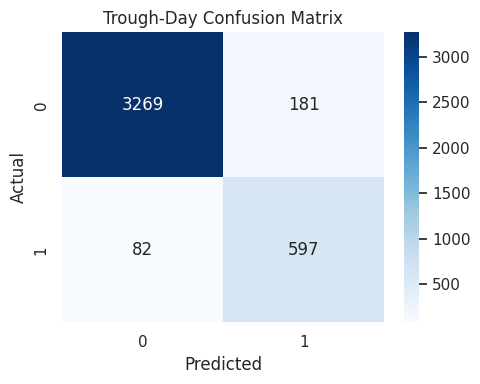

,Feature,Importance
3,Day_of_Week,0.217631
2,REGION_DESCRIPTION,0.023492
9,TGP_Lag_Proxy,0.011407
7,Distance_to_Terminal_km,0.004674
8,SEIFA_Score,-0.000799
5,Brand_Dominance,-0.000872
6,Competitor_Density,-0.001163
1,POSTCODE,-0.002034
4,Is_Weekend,-0.002325
0,BRAND_DESCRIPTION,-0.004529


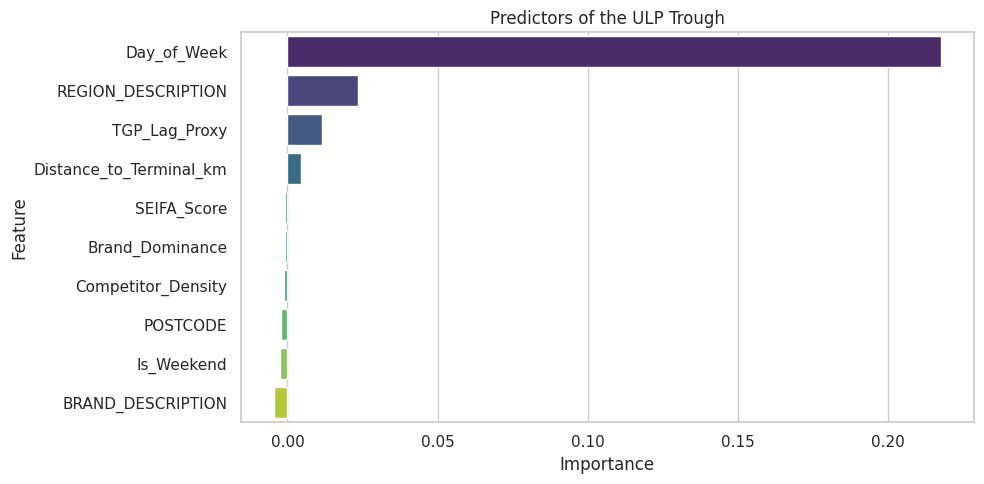

In [ ]:
# ==========================================
# REPLACE CURRENT CELL 7:
# Predict the trough of the ULP price cycle
# ==========================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

q2_df = ml_df.copy()
q2_df = q2_df[q2_df['PRODUCT_DESCRIPTION'].astype(str).str.upper() == 'ULP'].copy()
q2_df = q2_df.sort_values('PUBLISH_DATE').reset_index(drop=True)

# Define the weekly trough at region-day level
q2_df['ISO_WEEK'] = q2_df['PUBLISH_DATE'].dt.isocalendar().week.astype(int)

regional_daily = (
    q2_df.groupby(['REGION_DESCRIPTION', 'PUBLISH_DATE', 'ISO_WEEK'], as_index=False)['PRODUCT_PRICE']
         .mean()
         .rename(columns={'PRODUCT_PRICE': 'REGION_DAY_MEAN_PRICE'})
)

regional_daily['WEEKLY_REGION_MIN'] = (
    regional_daily.groupby(['REGION_DESCRIPTION', 'ISO_WEEK'])['REGION_DAY_MEAN_PRICE']
                .transform('min')
)
regional_daily['Is_Trough_Day'] = (
    regional_daily['REGION_DAY_MEAN_PRICE'] == regional_daily['WEEKLY_REGION_MIN']
).astype(int)

q2_df = q2_df.merge(
    regional_daily[['REGION_DESCRIPTION', 'PUBLISH_DATE', 'Is_Trough_Day']],
    on=['REGION_DESCRIPTION', 'PUBLISH_DATE'],
    how='left'
)

# Stronger proposal-aligned predictors
if 'Brand_Dominance' not in q2_df.columns:
    brand_counts = (
        q2_df.groupby(['POSTCODE', 'BRAND_DESCRIPTION'])
             .size()
             .reset_index(name='brand_station_count')
    )
    postcode_totals = (
        brand_counts.groupby('POSTCODE')['brand_station_count']
                    .sum()
                    .reset_index(name='postcode_station_count')
    )
    brand_counts = brand_counts.merge(postcode_totals, on='POSTCODE', how='left')
    brand_counts['Brand_Dominance'] = (
        brand_counts['brand_station_count'] / brand_counts['postcode_station_count']
    )
    q2_df = q2_df.merge(
        brand_counts[['POSTCODE', 'BRAND_DESCRIPTION', 'Brand_Dominance']],
        on=['POSTCODE', 'BRAND_DESCRIPTION'],
        how='left'
    )

feature_cols = [
    'BRAND_DESCRIPTION', 'POSTCODE', 'REGION_DESCRIPTION', 'Day_of_Week',
    'Is_Weekend', 'Brand_Dominance', 'Competitor_Density',
    'Distance_to_Terminal_km', 'SEIFA_Score', 'TGP_Lag_Proxy'
]
feature_cols = [c for c in feature_cols if c in q2_df.columns]

X_q2 = q2_df[feature_cols].copy()
y_q2 = q2_df['Is_Trough_Day'].copy()

categorical_cols = [
    c for c in ['BRAND_DESCRIPTION', 'POSTCODE', 'REGION_DESCRIPTION', 'Day_of_Week']
    if c in X_q2.columns
]
numeric_cols = [c for c in X_q2.columns if c not in categorical_cols]

prep_q2 = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols)
    ]
)

rf_clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

q2_model = Pipeline([
    ('prep', prep_q2),
    ('model', rf_clf)
])

print("Trough class balance:")
print(y_q2.value_counts(normalize=True).rename('proportion'))

tscv = TimeSeriesSplit(n_splits=5)
cv_auc = cross_validate(
    q2_model,
    X_q2,
    y_q2,
    cv=tscv,
    scoring={'auc': 'roc_auc', 'f1': 'f1', 'recall': 'recall'},
    n_jobs=-1
)

print(f"\n AUC   : {cv_auc['test_auc'].mean():.3f}")
print(f" F1    : {cv_auc['test_f1'].mean():.3f}")
print(f" Recall: {cv_auc['test_recall'].mean():.3f}")

split_idx = int(len(q2_df) * 0.8)
X_train_q2, X_test_q2 = X_q2.iloc[:split_idx], X_q2.iloc[split_idx:]
y_train_q2, y_test_q2 = y_q2.iloc[:split_idx], y_q2.iloc[split_idx:]

q2_model.fit(X_train_q2, y_train_q2)
y_pred_q2 = q2_model.predict(X_test_q2)
y_prob_q2 = q2_model.predict_proba(X_test_q2)[:, 1]

print("\nHoldout AUC:", roc_auc_score(y_test_q2, y_prob_q2))
print("\nClassification report:")
print(classification_report(y_test_q2, y_pred_q2))

cm = confusion_matrix(y_test_q2, y_pred_q2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Trough-Day Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

perm_q2 = permutation_importance(
    q2_model, X_test_q2, y_test_q2,
    n_repeats=10, random_state=42, n_jobs=-1
)

q2_importance = (
    pd.DataFrame({
        'Feature': X_test_q2.columns,
        'Importance': perm_q2.importances_mean
    })
    .sort_values('Importance', ascending=False)
)

display(q2_importance)

plt.figure(figsize=(10, 5))
sns.barplot(data=q2_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Predictors of the ULP Trough')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# ADD AFTER CURRENT CELL 4: Q2 FEATURE
# Brand dominance = local share of a brand within a postcode
# ==========================================
brand_counts = (
    ml_df.groupby(['POSTCODE', 'BRAND_DESCRIPTION'])
         .size()
         .reset_index(name='brand_station_count')
)

postcode_totals = (
    brand_counts.groupby('POSTCODE')['brand_station_count']
                .sum()
                .reset_index(name='postcode_station_count')
)

brand_counts = brand_counts.merge(postcode_totals, on='POSTCODE', how='left')
brand_counts['Brand_Dominance'] = (
    brand_counts['brand_station_count'] / brand_counts['postcode_station_count']
)

ml_df = ml_df.merge(
    brand_counts[['POSTCODE', 'BRAND_DESCRIPTION', 'Brand_Dominance']],
    on=['POSTCODE', 'BRAND_DESCRIPTION'],
    how='left'
)

# Resolve potential column naming conflicts if cell is run multiple times
if 'Brand_Dominance_y' in ml_df.columns:
    ml_df['Brand_Dominance'] = ml_df['Brand_Dominance_y']
    ml_df = ml_df.drop(columns=['Brand_Dominance_y'])
if 'Brand_Dominance_x' in ml_df.columns:
    ml_df = ml_df.drop(columns=['Brand_Dominance_x'])

print("✅ Engineered extra feature: Brand_Dominance")
display(ml_df[['POSTCODE', 'BRAND_DESCRIPTION', 'Brand_Dominance']].drop_duplicates().head())

✅ Engineered extra feature: Brand_Dominance


,POSTCODE,BRAND_DESCRIPTION,Brand_Dominance
0,6208,United,0.300000
1,6642,Independent,0.285714
2,6642,BP,0.285714
4,6330,Metro Petroleum,0.054054
8,6054,Metro Petroleum,0.210526


In [ ]:
print("--- Columns in ml_df after engineering Brand_Dominance ---")
display(ml_df.columns)

--- Columns in ml_df after engineering Brand_Dominance ---


Index(['PUBLISH_DATE', 'BRAND_DESCRIPTION', 'POSTCODE', 'REGION_DESCRIPTION',
       'PRODUCT_DESCRIPTION', 'Day_of_Week', 'Is_Weekend',
       'Competitor_Density', 'Distance_to_Terminal_km', 'SEIFA_Score',
       'TGP_Lag_Proxy', 'PRODUCT_PRICE', 'Brand_Dominance_x',
       'Brand_Dominance_y'],
      dtype='object')

In [ ]:
# ==========================================
# REPLACE / ADD AFTER CURRENT CELL 3:
# Q1 - ANOVA + Spatial Autocorrelation (Moran's I)
# ==========================================
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran
from splot.esda import plot_moran

analysis_df = df.copy()

# Robust metro / regional class: Explicitly use REGION_DESCRIPTION for 'Metropolitan' check
analysis_df['AREA_CLASS'] = np.where(
    analysis_df['REGION_DESCRIPTION'].astype(str).str.contains('metro', case=False, na=False),
    'Metropolitan',
    'Regional'
)

# Keep main fuel products for comparison
fuel_keep = ['ULP', 'DIESEL', 'PULP', '98 RON', '95 RON']
analysis_df = analysis_df[
    analysis_df['PRODUCT_DESCRIPTION'].astype(str).str.upper().isin([x.upper() for x in fuel_keep])
].copy()

print("Rows used for Q1:", len(analysis_df))
display(analysis_df[['PUBLISH_DATE', 'AREA_CLASS', 'REGION_DESCRIPTION',
                     'PRODUCT_DESCRIPTION', 'PRODUCT_PRICE']].head())

print("\n--- Q1A. Two-way ANOVA: Area class x Fuel type ---")

# Check if both 'Metropolitan' and 'Regional' categories exist after filtering
if analysis_df['AREA_CLASS'].nunique() < 2:
    print(f"❌ ANOVA for AREA_CLASS cannot be performed: Only one unique AREA_CLASS found ({analysis_df['AREA_CLASS'].iloc[0]}) after product filtering.")
    print("This might be due to all 'Metropolitan' or 'Regional' areas being filtered out for the selected fuel types.")
else:
    # Check for empty or single-observation groups in interaction cells
    group_counts = analysis_df.groupby(['AREA_CLASS', 'PRODUCT_DESCRIPTION']).size()
    print("\nCounts for each AREA_CLASS and PRODUCT_DESCRIPTION combination:")
    display(group_counts)

    # Identify groups with less than 2 observations (critical for interaction ANOVA)
    problematic_groups_interaction = group_counts[group_counts < 2]

    anova_formula = 'PRODUCT_PRICE ~ C(AREA_CLASS) + C(PRODUCT_DESCRIPTION) + C(AREA_CLASS):C(PRODUCT_DESCRIPTION)'
    if not problematic_groups_interaction.empty:
        print("\n⚠️ Warning: The following groups have insufficient data for robust ANOVA with interaction term:")
        display(problematic_groups_interaction)
        print("This likely causes the 'ValueError: must have at least one row in constraint matrix' when calculating ANOVA for the interaction term.")
        print("Proceeding with a simpler ANOVA model without the interaction term.")
        anova_formula = 'PRODUCT_PRICE ~ C(AREA_CLASS) + C(PRODUCT_DESCRIPTION)' # Fallback to additive model

    try:
        anova_model = ols(anova_formula,
            data=analysis_df
        ).fit()

        anova_table = sm.stats.anova_lm(anova_model, typ=2)
        display(anova_table)

        # Optional assumption checks
        sample_for_normality = analysis_df['PRODUCT_PRICE'].sample(
            min(1000, len(analysis_df)), random_state=42
        )
        print("Shapiro-Wilk p-value:", stats.shapiro(sample_for_normality).pvalue)

        # Ensure area_groups has enough elements for Levene's test
        area_groups = [
            g['PRODUCT_PRICE'].values
            for _, g in analysis_df.groupby(['AREA_CLASS', 'PRODUCT_DESCRIPTION'])
            if len(g) > 1
        ]
        if len(area_groups) >= 2:
            print("Levene p-value:", stats.levene(*area_groups).pvalue)
        else:
            print("⚠️ Not enough groups with sufficient data to perform Levene's test for homoscedasticity.")

    except ValueError as e:
        print(f"\n❌ ERROR during ANOVA calculation: {e}")
        print("Even after simplification, the ANOVA failed. This might indicate issues with main effects categories having too few observations or other data irregularities.")


print("\n--- Q1B. Global Moran's I on average ULP price ---")
ulp = analysis_df[analysis_df['PRODUCT_DESCRIPTION'].astype(str).str.upper() == 'ULP'].copy()

# Try to find coordinates in the raw extract first
lat_candidates = ['LATITUDE', 'Latitude', 'latitude', 'LAT']
lon_candidates = ['LONGITUDE', 'Longitude', 'longitude', 'LON', 'LONG']
lat_col = next((c for c in lat_candidates if c in ulp.columns), None)
lon_col = next((c for c in lon_candidates if c in ulp.columns), None)

# If raw coordinates are absent, try postcode centroid lookup
if (lat_col is None or lon_col is None) and Path('wa_postcode_centroids.csv').exists():
    centroid_df = pd.read_csv('wa_postcode_centroids.csv')
    centroid_lat = next((c for c in lat_candidates if c in centroid_df.columns), None)
    centroid_lon = next((c for c in lon_candidates if c in centroid_df.columns), None)
    if centroid_lat and centroid_lon and 'POSTCODE' in centroid_df.columns:
        ulp = ulp.merge(
            centroid_df[['POSTCODE', centroid_lat, centroid_lon]].drop_duplicates(),
            on='POSTCODE',
            how='left'
        )
        lat_col, lon_col = centroid_lat, centroid_lon

if lat_col is None or lon_col is None:
    print("⚠️ Moran's I not computed because no coordinates were found.")
    print("   Add LATITUDE/LONGITUDE columns to the CSV, or upload wa_postcode_centroids.csv and rerun this cell.")
else:
    station_key = next(
        (c for c in ['ADDRESS', 'LOCATION', 'TRADING_NAME', 'SITE_NAME', 'POSTCODE'] if c in ulp.columns),
        'POSTCODE'
    )

    moran_df = (
        ulp.dropna(subset=[lat_col, lon_col])
           .groupby([station_key, 'POSTCODE', lat_col, lon_col], as_index=False)['PRODUCT_PRICE']
           .mean()
           .rename(columns={'PRODUCT_PRICE': 'AVG_ULP_PRICE'})
    )

    if len(moran_df) < 4:
        print("⚠️ Not enough spatial points to compute Moran's I.")
    else:
        gdf = gpd.GeoDataFrame(
            moran_df,
            geometry=gpd.points_from_xy(moran_df[lon_col], moran_df[lat_col]),
            crs='EPSG:4326'
        ).to_crs(3857)

        k = min(8, len(gdf) - 1)
        w = KNN.from_dataframe(gdf, k=k)
        w.transform = 'R'

        moran = Moran(gdf['AVG_ULP_PRICE'].values, w)

        print(f"Moran's I: {moran.I:.4f}")
        print(f"p-value  : {moran.p_sim:.4f}")
        if moran.p_sim < 0.05 and moran.I > 0:
            print("✅ Significant positive spatial clustering detected.")
        elif moran.p_sim < 0.05 and moran.I < 0:
            print("✅ Significant negative spatial dispersion detected.")
        else:
            print("ℹ️ No statistically significant spatial autocorrelation detected.")

        fig, ax = plt.subplots(figsize=(8, 5))
        plot_moran(moran, zstandard=True, ax=ax)
        plt.title("Global Moran's I for Average ULP Price")
        plt.tight_layout()
        plt.show()

Rows used for Q1: 65606


,PUBLISH_DATE,AREA_CLASS,REGION_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE
0,2026-02-01,Regional,Peel,ULP,179.9
1,2026-02-01,Regional,Peel,Diesel,184.9
2,2026-02-01,Regional,Peel,98 RON,192.9
3,2026-02-01,Metropolitan,Metro,ULP,159.9
4,2026-02-01,Metropolitan,Metro,PULP,174.9



--- Q1A. Two-way ANOVA: Area class x Fuel type ---

Counts for each AREA_CLASS and PRODUCT_DESCRIPTION combination:


AREA_CLASS    PRODUCT_DESCRIPTION
Metropolitan  98 RON                 12289
              Diesel                  5995
              PULP                   10323
              ULP                    12569
Regional      98 RON                  5879
              Diesel                  6752
              PULP                    3724
              ULP                     8075
dtype: int64

,sum_sq,df,F,PR(>F)
C(AREA_CLASS),1.507879e+06,1.0,9485.099502,0.000000e+00
C(PRODUCT_DESCRIPTION),5.391128e+06,3.0,11304.039670,0.000000e+00
C(AREA_CLASS):C(PRODUCT_DESCRIPTION),6.837035e+04,3.0,143.357975,1.360649e-92
Residual,1.042834e+07,65598.0,NaN,NaN


Shapiro-Wilk p-value: 6.003427047329705e-12
Levene p-value: 1.1795763139765524e-304

--- Q1B. Global Moran's I on average ULP price ---
⚠️ Moran's I not computed because no coordinates were found.
   Add LATITUDE/LONGITUDE columns to the CSV, or upload wa_postcode_centroids.csv and rerun this cell.


In [ ]:
# ==========================================
# FINAL CELL: Save all outputs and download as ZIP
# ==========================================

import os
import shutil
from google.colab import files

# -----------------------------
# 1. Create output folder
# -----------------------------
output_dir = "fuel_project_outputs"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# 2. Save key tables / datasets
# -----------------------------
# Raw cleaned / working datasets
try:
    df.to_csv(f"{output_dir}/01_raw_loaded_dataset.csv", index=False)
except:
    print("df not found")

try:
    ml_df.to_csv(f"{output_dir}/02_feature_engineered_dataset.csv", index=False)
except:
    print("ml_df not found")

try:
    importance_df.to_csv(f"{output_dir}/03_feature_importance.csv", index=False)
except:
    print("importance_df not found")

try:
    results_df.to_csv(f"{output_dir}/04_prediction_results.csv", index=False)
except:
    print("results_df not found")

# ANOVA / test outputs
try:
    anova_table.to_csv(f"{output_dir}/05_anova_results.csv")
except:
    print("anova_table not found")

# Missing values summary
try:
    missing_summary_df = pd.DataFrame(df.isnull().sum(), columns=["Missing_Count"])
    missing_summary_df.to_csv(f"{output_dir}/06_missing_values_summary.csv")
except:
    print("Missing summary could not be saved")

# Dataset info summary
try:
    dataset_info_df = pd.DataFrame({
        "Column": df.columns,
        "Dtype": [str(x) for x in df.dtypes]
    })
    dataset_info_df.to_csv(f"{output_dir}/07_dataset_info.csv", index=False)
except:
    print("dataset_info_df could not be saved")

# Model metrics summary
try:
    metrics_df = pd.DataFrame({
        "Metric": ["RMSE", "MAE", "R2"],
        "Value": [rmse, mae, r2]
    })
    metrics_df.to_csv(f"{output_dir}/08_model_metrics.csv", index=False)
except:
    print("metrics_df could not be saved")

# Q2 outputs if available
try:
    q2_importance.to_csv(f"{output_dir}/09_q2_feature_importance.csv", index=False)
except:
    print("q2_importance not found")

try:
    q2_class_report = pd.DataFrame(classification_report(y_test_q2, y_pred_q2, output_dict=True)).transpose()
    q2_class_report.to_csv(f"{output_dir}/10_q2_classification_report.csv")
except:
    print("Q2 classification report not found")

# -----------------------------
# 3. Save figures as PNG
# -----------------------------

# Figure 1: ULP price by region boxplot
try:
    plt.figure(figsize=(14, 7))
    order = ulp_data.groupby('REGION_DESCRIPTION')['PRODUCT_PRICE'].mean().sort_values().index
    sns.boxplot(data=ulp_data, x='REGION_DESCRIPTION', y='PRODUCT_PRICE', order=order)
    plt.title('Distribution of Unleaded Petrol (ULP) Prices by Region (Feb 2026)', fontsize=14)
    plt.xlabel('Region')
    plt.ylabel('Price (Cents per Litre)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/figure_01_ulp_price_by_region_boxplot.png", dpi=300, bbox_inches="tight")
    plt.close()
except:
    print("Could not save Figure 1")

# Figure 2: Random Forest feature importance
try:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
    plt.title('Random Forest - Feature Importance (Top Predictors of Fuel Price)', fontsize=14)
    plt.xlabel('Relative Importance')
    plt.ylabel('Explanatory Variables')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/figure_02_random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.close()
except:
    print("Could not save Figure 2")

# Figure 3: Actual vs Predicted scatter
try:
    plt.figure(figsize=(7, 7))
    plt.scatter(results_df['PRODUCT_PRICE'], results_df['PREDICTED_PRICE'], alpha=0.5)
    min_val = min(results_df['PRODUCT_PRICE'].min(), results_df['PREDICTED_PRICE'].min())
    max_val = max(results_df['PRODUCT_PRICE'].max(), results_df['PREDICTED_PRICE'].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.title("Actual vs Predicted Fuel Prices", fontsize=14)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/figure_03_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
    plt.close()
except:
    print("Could not save Figure 3")

# Figure 4: Prediction error distribution
try:
    plt.figure(figsize=(10, 5))
    sns.histplot(results_df['PREDICTION_ERROR'], bins=30, kde=True)
    plt.title("Prediction Error Distribution", fontsize=14)
    plt.xlabel("Absolute Prediction Error")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/figure_04_prediction_error_distribution.png", dpi=300, bbox_inches="tight")
    plt.close()
except:
    print("Could not save Figure 4")

# Figure 5: Q2 confusion matrix if available
try:
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test_q2, y_pred_q2)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Trough-Day Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/figure_05_q2_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.close()
except:
    print("Could not save Figure 5")

# Figure 6: Q2 feature importance if available
try:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=q2_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('Predictors of the ULP Trough', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/figure_06_q2_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.close()
except:
    print("Could not save Figure 6")

# -----------------------------
# 4. Save text summary
# -----------------------------
try:
    with open(f"{output_dir}/README_summary.txt", "w") as f:
        f.write("Fuel Project Outputs Summary\n")
        f.write("============================\n\n")
        f.write("Saved outputs include:\n")
        f.write("- Raw / processed datasets\n")
        f.write("- Missing values and dataset info tables\n")
        f.write("- ANOVA results\n")
        f.write("- Random Forest evaluation metrics\n")
        f.write("- Feature importance tables\n")
        f.write("- Prediction result tables\n")
        f.write("- Main figures as PNG files\n")
        f.write("- Q2 classification outputs if available\n\n")
        try:
            f.write(f"Main model RMSE: {rmse:.2f}\n")
            f.write(f"Main model MAE : {mae:.2f}\n")
            f.write(f"Main model R2  : {r2:.4f}\n")
        except:
            pass
except:
    print("README could not be saved")

# -----------------------------
# 5. Zip the folder
# -----------------------------
zip_path = shutil.make_archive(output_dir, 'zip', output_dir)

print("✅ All outputs saved successfully.")
print("✅ ZIP file created:", zip_path)

# -----------------------------
# 6. Download ZIP
# -----------------------------
files.download(zip_path)

✅ All outputs saved successfully.
✅ ZIP file created: /content/fuel_project_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>